<a href="https://colab.research.google.com/github/moigabone/CPE_Project_Samai_Team/blob/main/project_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Basic configuration for clean plot styling
sns.set_theme(style="whitegrid")

# Load the dataset
# Ensure the file is named 'heart.csv' and uploaded to your Colab environment
df = pd.read_csv('/heart.csv')

# Display dataset shape and the first 5 rows
print(f"Dataset dimensions: {df.shape[0]} rows and {df.shape[1]} columns.")
display(df.head())

Dataset dimensions: 1025 rows and 14 columns.


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [2]:
# 1. Check for missing values
print("--- Missing values per column ---")
print(df.isnull().sum())
print("\n")

# 2. Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# 3. Drop duplicates (if any)
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Duplicates removed. New dataset dimensions: {df.shape}")
else:
    print("No duplicates to remove.")

# 4. Check data types to ensure there are no formatting errors
print("\n--- Data Types ---")
df.info()

--- Missing values per column ---
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


Number of duplicate rows: 723
Duplicates removed. New dataset dimensions: (302, 14)

--- Data Types ---
<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 0 to 878
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  

/tmp/ipykernel_7038/3965281590.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='target', palette='Set2', ax=axes[0])


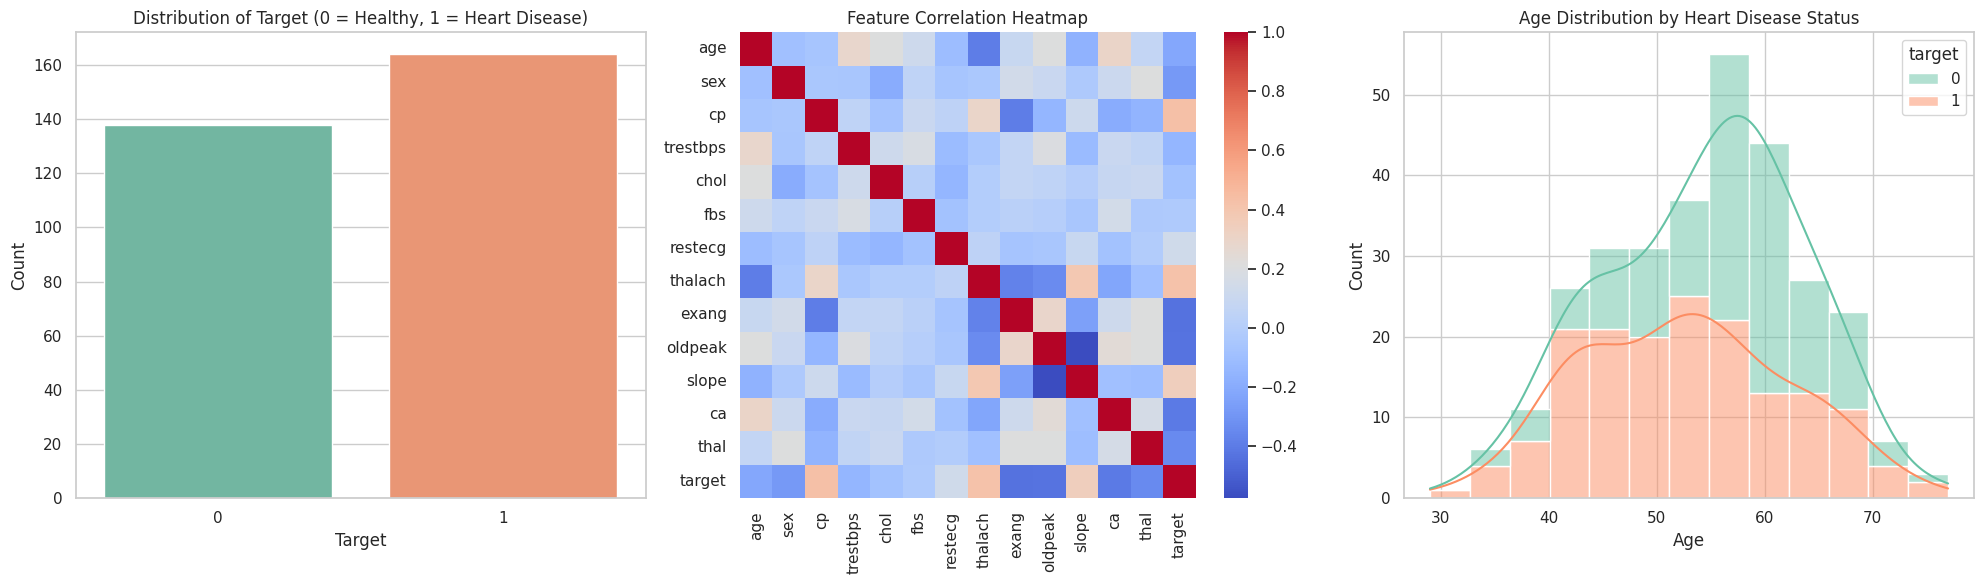

--- Top correlations with the Target variable ---
cp         0.432080
thalach    0.419955
slope      0.343940
Name: target, dtype: float64
ca        -0.408992
oldpeak   -0.429146
exang     -0.435601
Name: target, dtype: float64


In [3]:

# Create a figure with multiple subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: Distribution of the target variable
sns.countplot(data=df, x='target', palette='Set2', ax=axes[0])
axes[0].set_title('Distribution of Target (0 = Healthy, 1 = Heart Disease)')
axes[0].set_xlabel('Target')
axes[0].set_ylabel('Count')

# Plot 2: Correlation Heatmap
# This shows how strongly each feature is related to the target and to each other
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', ax=axes[1])
axes[1].set_title('Feature Correlation Heatmap')

# Plot 3: Age Distribution by Target
sns.histplot(data=df, x='age', hue='target', multiple='stack', palette='Set2', kde=True, ax=axes[2])
axes[2].set_title('Age Distribution by Heart Disease Status')
axes[2].set_xlabel('Age')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Print the top 5 features most correlated with the target
print("--- Top correlations with the Target variable ---")
correlations = df.corr()['target'].sort_values(ascending=False)
print(correlations.drop('target').head(3)) # Top 3 positive correlations
print(correlations.drop('target').tail(3)) # Top 3 negative correlations

In [4]:
# ---------------------------------------------------------
# Feature Engineering and Data Splitting
# ---------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = df.drop('target', axis=1)
y = df['target']

# Split the dataset into 80% training and 20% testing
# random_state is set to 42 for reproducibility (required by guidelines)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features (important for models like KNN and Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Step 4 complete: Data split and scaled successfully!\n")

# ---------------------------------------------------------
# Machine Learning Model Training
# ---------------------------------------------------------
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Initialize the three models
log_reg = LogisticRegression(random_state=42)
rf_model = RandomForestClassifier(random_state=42)
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the models on the scaled training data
log_reg.fit(X_train_scaled, y_train)
rf_model.fit(X_train_scaled, y_train)
knn_model.fit(X_train_scaled, y_train)

# Make predictions on the test set and calculate accuracy
print("--- Initial Model Accuracy Scores ---")
print(f"Logistic Regression: {accuracy_score(y_test, log_reg.predict(X_test_scaled)):.4f}")
print(f"Random Forest:       {accuracy_score(y_test, rf_model.predict(X_test_scaled)):.4f}")
print(f"K-Nearest Neighbors: {accuracy_score(y_test, knn_model.predict(X_test_scaled)):.4f}")

Step 4 complete: Data split and scaled successfully!

--- Initial Model Accuracy Scores ---
Logistic Regression: 0.7705
Random Forest:       0.8361
K-Nearest Neighbors: 0.7377


--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.89      0.78      0.83        32
           1       0.79      0.90      0.84        29

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



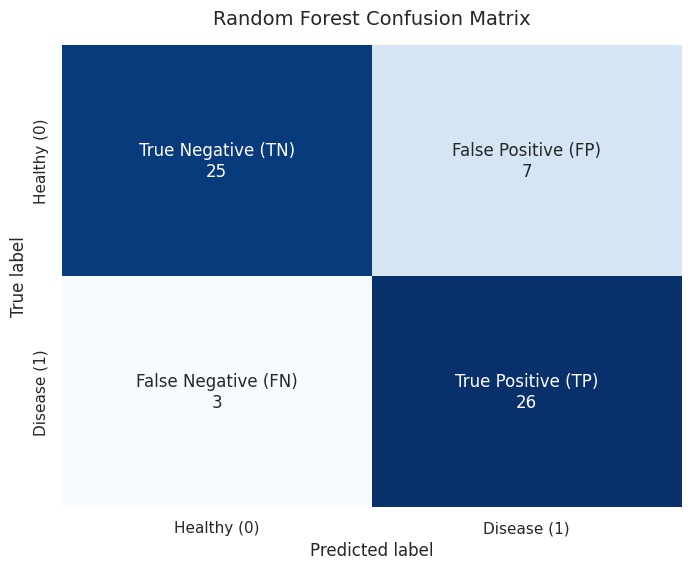

In [5]:
# ---------------------------------------------------------
#  Detailed Model Evaluation (Focus on Random Forest)
# ---------------------------------------------------------
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# We focus on the best performing model: Random Forest
y_pred_rf = rf_model.predict(X_test_scaled)

# 1. Print Classification Report (Precision, Recall, F1-Score)
print("--- Random Forest Classification Report ---")
print(classification_report(y_test, y_pred_rf))

# 2. Plot Enhanced Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)

# Create custom labels (TN, FP, FN, TP)
group_names = ['True Negative (TN)', 'False Positive (FP)',
               'False Negative (FN)', 'True Positive (TP)']
group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]

# Combine text and counts
labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_names, group_counts)]
labels = np.asarray(labels).reshape(2,2)

# Plot using Seaborn Heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues',
            xticklabels=['Healthy (0)', 'Disease (1)'],
            yticklabels=['Healthy (0)', 'Disease (1)'],
            cbar=False, annot_kws={"size": 12})

plt.title('Random Forest Confusion Matrix', fontsize=14, pad=15)
plt.xlabel('Predicted label', fontsize=12)
plt.ylabel('True label', fontsize=12)
plt.show()